# Using the clusters

In [1]:
import gsw
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import sys, pandas as pd
from pathlib import Path
from xhistogram.xarray import histogram as xhist

# month labels, shared by every 12-panel monthly plot below
labs = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
        'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
cluster = "F"

In [2]:
sys.path.insert(0, "/work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/"
                   "kmeans_analysis/kmean_analysis_30_180_stdZ_w")
import config as C

In [3]:
def select_cluster(group):
    """Every particle in one k-means group as a table (trajectory_id ->
    store_index + local). Reads only the label parquet, no trajectory data."""
    gid = {v: k for k, v in C.GROUP_NAMES.items()}[group]        # 'F' -> 6

    lab = pd.read_parquet(C.LABELED_FILE, columns=["trajectory_id", "cluster_group"])
    tid = lab.loc[lab.cluster_group == gid, "trajectory_id"].to_numpy()

    sel = pd.DataFrame({"trajectory_id": tid,
                        "store_index":   tid // C.TRAJ_PER_STORE,
                        "local":         tid %  C.TRAJ_PER_STORE})

    print(f"group {group} (id {gid}): {len(sel):,} particles "
          f"across {sel.store_index.nunique()} stores")
    return sel


In [4]:
sel = select_cluster(cluster) 
sel

group F (id 6): 149,215 particles across 1024 stores


,trajectory_id,store_index,local
0,93,0,93
1,1850,0,1850
2,2536,0,2536
3,3213,0,3213
4,3303,0,3303
...,...,...,...
149210,16277835,1627,7835
149211,16278119,1627,8119
149212,16279374,1627,9374
149213,16279601,1627,9601


In [5]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46459 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:46459/status,
Dashboard: http://127.0.0.1:46459/status,Workers: 4
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34759,Workers: 0
Dashboard: http://127.0.0.1:46459/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45819,Total threads: 3
Dashboard: http://127.0.0.1:36643/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:42447,


In [6]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [7]:
stores1 = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678").glob("Parcels_run_*_*.zarr"))
stores2  = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_67891").glob("Parcels_run_*_*.zarr"))
stores3 = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_78876").glob("Parcels_run_*_*.zarr"))

stores = stores1+stores2+stores3
stores[:3]

[PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-06 00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-11 00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-16 00:00:00.zarr')]

In [8]:
# the .zarr stores that contain group-F particles (full paths)
cluster_stores = [stores[i] for i in sorted(sel.store_index.unique())]
print(f"group F lives in {len(cluster_stores)} stores")
cluster_stores[:3]


group F (id 6): 149,215 particles across 1024 stores
group F lives in 1024 stores


[PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-06 00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-03-17 00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-03-27 00:00:00.zarr')]

In [29]:
ds_list = []
for si, g in sel.groupby("store_index"):
    d = xr.open_zarr(stores[si]).isel(trajectory=g.local.to_numpy())
    ds_list.append(d)
ds = xr.concat(ds_list, dim='trajectory')
ds

<xarray.Dataset> Size: 6GB
Dimensions:     (trajectory: 149215, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 1MB 93 1850 2536 3213 ... 8119 9374 9601 9757
Data variables:
    lat         (trajectory, obs) float64 1GB dask.array<chunksize=(19, 185), meta=np.ndarray>
    lon         (trajectory, obs) float64 1GB dask.array<chunksize=(19, 185), meta=np.ndarray>
    sal         (trajectory, obs) float32 552MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    temp        (trajectory, obs) float32 552MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 1GB dask.array<chunksize=(19, 185), meta=np.ndarray>
    z           (trajectory, obs) float64 1GB dask.array<chunksize=(19, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [30]:
num_valid_obs_steps = int(ds.lat.notnull().any('trajectory').sum().compute().data[()])
ds = ds.isel(obs=slice(None, num_valid_obs_steps))
ds

<xarray.Dataset> Size: 4GB
Dimensions:     (trajectory: 149215, obs: 740)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 733 734 735 736 737 738 739
  * trajectory  (trajectory) int64 1MB 93 1850 2536 3213 ... 8119 9374 9601 9757
Data variables:
    lat         (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    lon         (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    sal         (trajectory, obs) float32 442MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    temp        (trajectory, obs) float32 442MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    z           (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [31]:
ds = ds.assign(start_time=ds.time.isel(obs=0).compute())

In [32]:
lat_min=ds.lat.min().compute().data[()]
lon_min=ds.lon.min().compute().data[()]

lat_max=ds.lat.max().compute().data[()]
lon_max=ds.lon.max().compute().data[()]

In [33]:
lat_bins = np.linspace(lat_min, lat_max, 30)
lon_bins = np.linspace(lon_min, lon_max, 80)

In [35]:
def calc_hist(ds):
    return xhist(
        ds.lon,
        ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory", ],
        bin_dim_suffix=""
    )

In [36]:
ds_m = ds.assign(start_month=ds.start_time.dt.month)
ds_m = ds_m.assign(start_year=ds.start_time.dt.year)
ds_m

<xarray.Dataset> Size: 4GB
Dimensions:      (trajectory: 149215, obs: 740)
Coordinates:
  * obs          (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 733 734 735 736 737 738 739
  * trajectory   (trajectory) int64 1MB 93 1850 2536 3213 ... 9374 9601 9757
Data variables:
    lat          (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    lon          (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    sal          (trajectory, obs) float32 442MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    temp         (trajectory, obs) float32 442MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    time         (trajectory, obs) datetime64[ns] 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    z            (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    start_time   (trajectory) datetime64[ns] 1MB 1993-01-06 ... 2013-08-20
    start_month  (trajectory) int64 1MB 1 1 1 1 1 1 1 1 1 ... 8 8 8 8 8 8 8 8 8
    start_year   (trajectory) int64 1MB 1993 1993 1993 1993 ... 2013 2013 2013
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [23]:
hist_monthly = ds_m.groupby(["start_month"]).apply(calc_hist)
hist_monthly = hist_monthly.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()

In [24]:
hist_monthly.drop_encoding().compute().to_netcdf(f"_hist_monthly_{cluster}.nc")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 14.44 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [4]:
hist_month = xr.open_dataset("_hist_monthly.nc").compute().histogram_lon_lat
hist_month

<xarray.DataArray 'histogram_lon_lat' (start_month: 12, obs: 36, lon: 79,
                                       lat: 29)> Size: 8MB
array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
...
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]]], shape=(12, 36, 79, 29))
Coordinates:
  * obs          (obs) float64 288B 10.5 30.5 50.5 70.5 ... 670.5 690.5 710.5
  * lon          (lon) float64 632B -59.77 -58.9 -58.04 ... 5.876 6.74 7.604
  * lat          (lat) float64 232B -6.643 -5.736 -4.828 ... 16.96 17.87 18.78
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


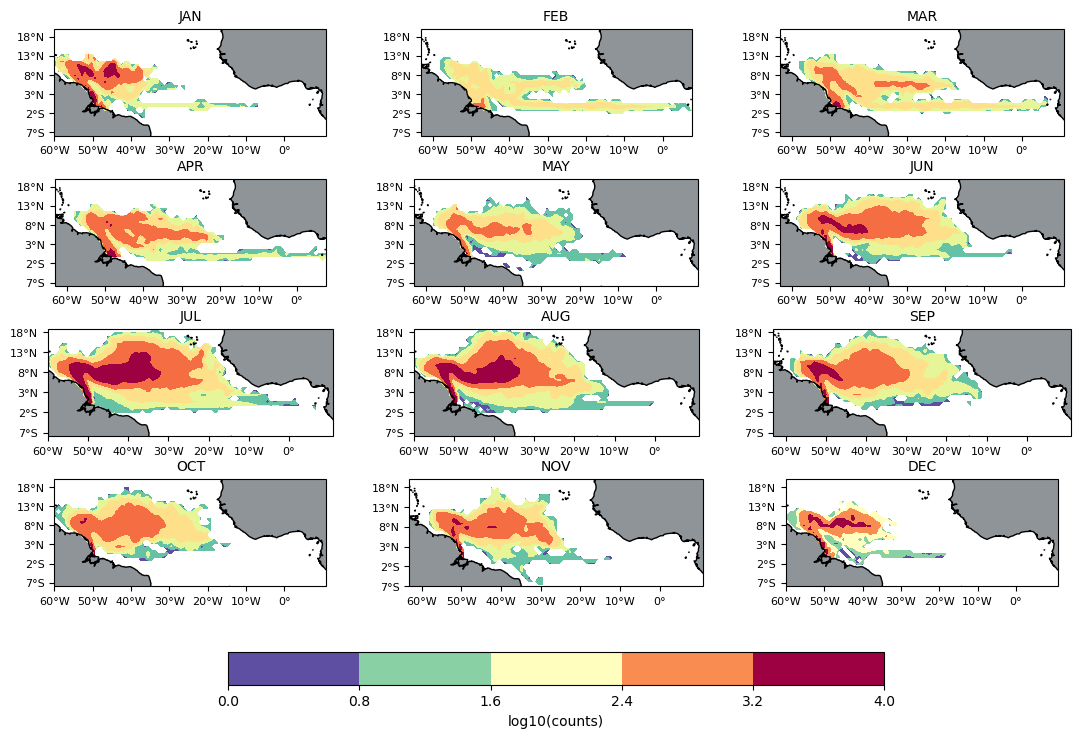

In [7]:
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(
    4, 3,
    figsize=(12, 8),                      # a bit wider, not so tall
    subplot_kw=dict(projection=proj)
)
ax = ax.ravel()

for i in range(12):
    dd = hist_month.sel(start_month=i+1).sum("obs")

    # plot
    pcm = np.log10(dd).plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=proj,
        add_colorbar=False, cmap='Spectral_r'
    )

    ax[i].coastlines()
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_title(labs[i], fontsize=10)

    # ticks & labels
    ax[i].set_xticks(
        np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10),
        crs=proj
    )
    ax[i].set_yticks(
        np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5),
        crs=proj
    )
    ax[i].xaxis.set_major_formatter(
        LongitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].yaxis.set_major_formatter(
        LatitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].tick_params(labelsize=8)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

# Tighter spacing: reduce both wspace and hspace
fig.subplots_adjust(
    left=0.05, right=0.95,
    bottom=0.08, top=0.90,
    wspace=0.05, hspace=0.4
)


# Optional: one shared colorbar at bottom
cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10
)
cbar.ax.set_xlabel('log10(counts)', fontsize=10)
plt.savefig(f"figures/mean_log10(counts)_LPT_{cluster}.png", dpi=300, bbox_inches="tight")
plt.show()

## Now the temp,sal,z

In [ ]:
def calc_one(d, v):
    """Binned sum and count for a SINGLE variable, weighted by that variable.
    Positions where the variable is NaN are excluded by masking the coordinates."""
    w = d[v]
    lon = d.lon.where(w.notnull())   # drop samples with no value for this var
    lat = d.lat.where(w.notnull())
    count = xhist(lon, lat, bins=[lon_bins, lat_bins],
                  dim=["trajectory"], bin_dim_suffix="")
    wsum  = xhist(lon, lat, bins=[lon_bins, lat_bins],
                  dim=["trajectory"], weights=w, bin_dim_suffix="")
    return xr.Dataset({"sum": wsum, "count": count})

# group by release month, one variable at a time
monthly_z    = ds_m.groupby("start_month").apply(lambda d: calc_one(d, "z"))
monthly_temp = ds_m.groupby("start_month").apply(lambda d: calc_one(d, "temp"))
monthly_sal  = ds_m.groupby("start_month").apply(lambda d: calc_one(d, "sal"))

In [39]:
def monthly_mean(m, name):
    """collapse the obs axis (skip the initial release position), then mean = sum / count"""
    m = m.isel(obs=slice(1, None)).sum("obs")
    mean = m["sum"] / m["count"].where(m["count"] > 0)
    return mean.rename(name).compute()

mean_z    = monthly_mean(monthly_z,    "z")
mean_temp = monthly_mean(monthly_temp, "temp")
mean_sal  = monthly_mean(monthly_sal,  "sal")

# store each one separately (zarr)
mean_z.to_dataset().to_zarr(f"mean_z_month_{cluster}.zarr",       mode="w")
mean_temp.to_dataset().to_zarr(f"mean_temp_month_{cluster}.zarr", mode="w")
mean_sal.to_dataset().to_zarr(f"mean_sal_month_{cluster}.zarr",   mode="w")


/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 19.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 19.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Send

In [9]:
mean_z = xr.open_dataset(f'mean_z_month_{cluster}.zarr').compute()
mean_sal = xr.open_dataset(f'mean_sal_month_{cluster}.zarr').compute()
mean_temp = xr.open_dataset(f'mean_temp_month_{cluster}.zarr').compute() 

In [29]:
from matplotlib.colors import BoundaryNorm
import cmocean as cm

# --- per-variable plotting config: colormap, colorbar label, discrete levels ---
# add a new variable by adding one entry to each of the three dicts.
cmaps = {
    "z":      "turbo",
    "temp":   cm.cm.balance,
    "sal":    "jet",
    "sigma0": 'tab20',      # sequential: darker = denser
    "b":      cm.cm.balance,    # diverging around 0: buoyant vs. dense
}
labels = {
    "z":      "mean depth [m]",
    "temp":   "mean temperature [°C]",
    "sal":    "mean salinity",
    "sigma0": r"mean $\sigma_0$ [kg m$^{-3}$]",
    "b":      r"mean buoyancy [m s$^{-2}$]",
}
LEVELS = {
    "z":      [0, 50, 100, 150, 200, 300, 400, 500],
    "temp":   [0, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30],
    "sal":    np.insert(np.arange(30, 36, 0.5), 0, 0),
    "sigma0": [5,10, 15, 18, 20, 21, 22, 23, 24, 25, 26, 27],   # <15 (plume) clipped to lowest band
    "b":      np.arange(-0.02, 0.16, 0.01),               # >0 = light plume water
}


def plot_monthly(da, name):
    """12-panel monthly map of `da`. Colormap, colorbar label and discrete
    contour levels are looked up from the cmaps/labels/LEVELS dicts by `name`."""
    cmap, label, levels = cmaps[name], labels[name], LEVELS[name]
    norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, clip=True)

    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(4, 3, figsize=(12, 8), subplot_kw=dict(projection=proj))
    ax = ax.ravel()

    for i in range(12):
        dd = da.sel(start_month=i + 1)

        pcm = dd.plot.contourf(
            x="lon", y="lat", ax=ax[i], transform=proj,
            cmap=cmap, levels=levels, norm=norm, add_colorbar=False,
        )

        ax[i].coastlines()
        ax[i].add_feature(cf.LAND, facecolor="#8e9497ff", zorder=0)
        ax[i].set_title(labs[i], fontsize=10)
        ax[i].set_xticks(
            np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10),
            crs=proj
        )
        ax[i].set_yticks(
            np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5),
            crs=proj
        )
        ax[i].xaxis.set_major_formatter(
            LongitudeFormatter(number_format=".0f", degree_symbol="°")
        )
        ax[i].yaxis.set_major_formatter(
            LatitudeFormatter(number_format=".0f", degree_symbol="°")
        )
        ax[i].tick_params(labelsize=8)
        ax[i].set_xlabel("")
        ax[i].set_ylabel("")

    fig.subplots_adjust(
        left=0.05, right=0.95,
        bottom=0.08, top=0.90,
        wspace=0.05, hspace=0.4
    )
    cbar = fig.colorbar(
        pcm, ax=ax, orientation="horizontal",
        fraction=0.05, pad=0.10
    )
    cbar.ax.set_xlabel(label, fontsize=10)
    plt.savefig(f"figures/mean_{name}_LPT_{cluster}.png", dpi=300, bbox_inches="tight")
    plt.show()

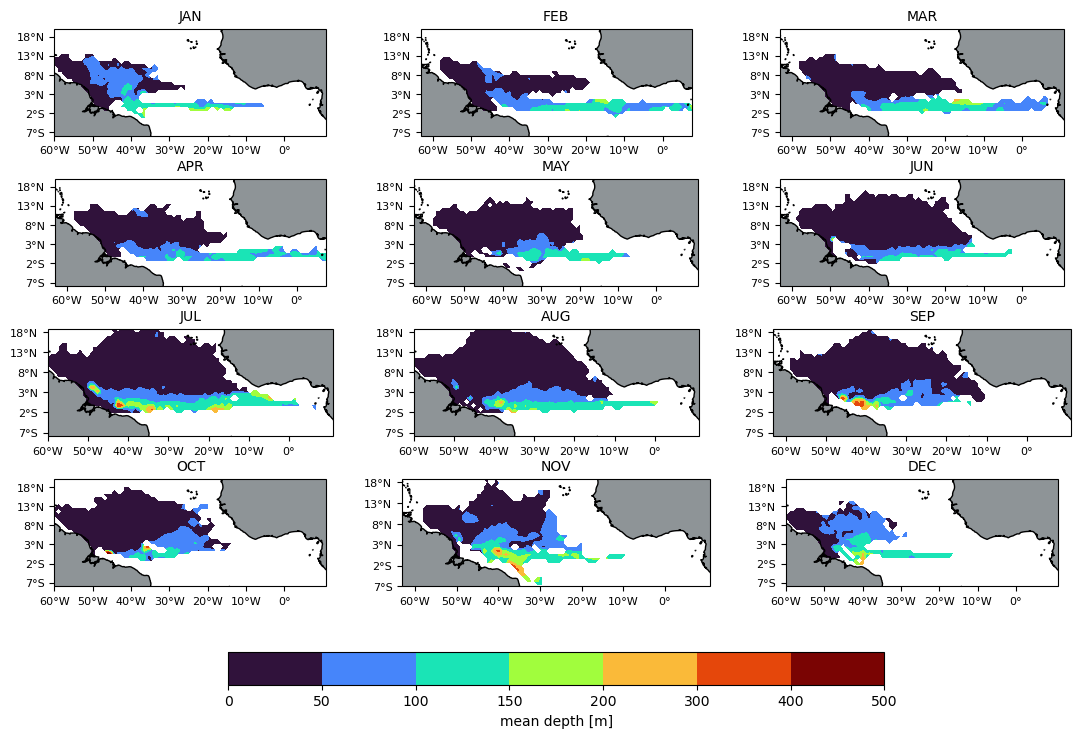

In [11]:
plot_monthly(mean_z.z, "z")

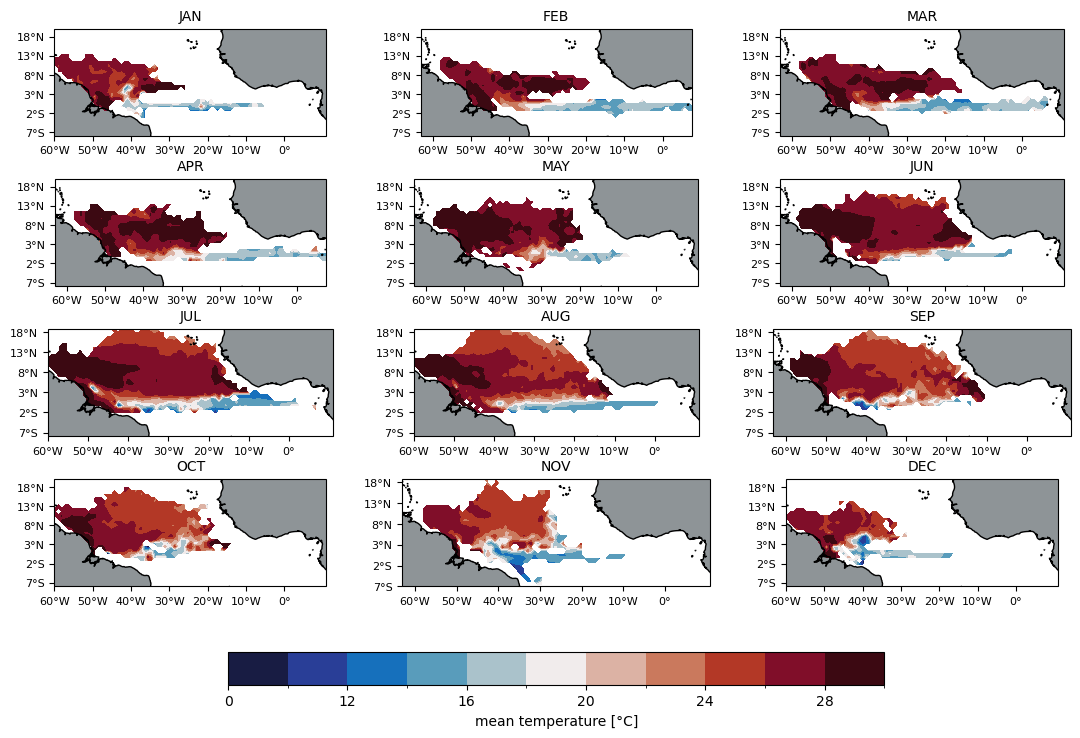

In [12]:
plot_monthly(mean_temp.temp, "temp")

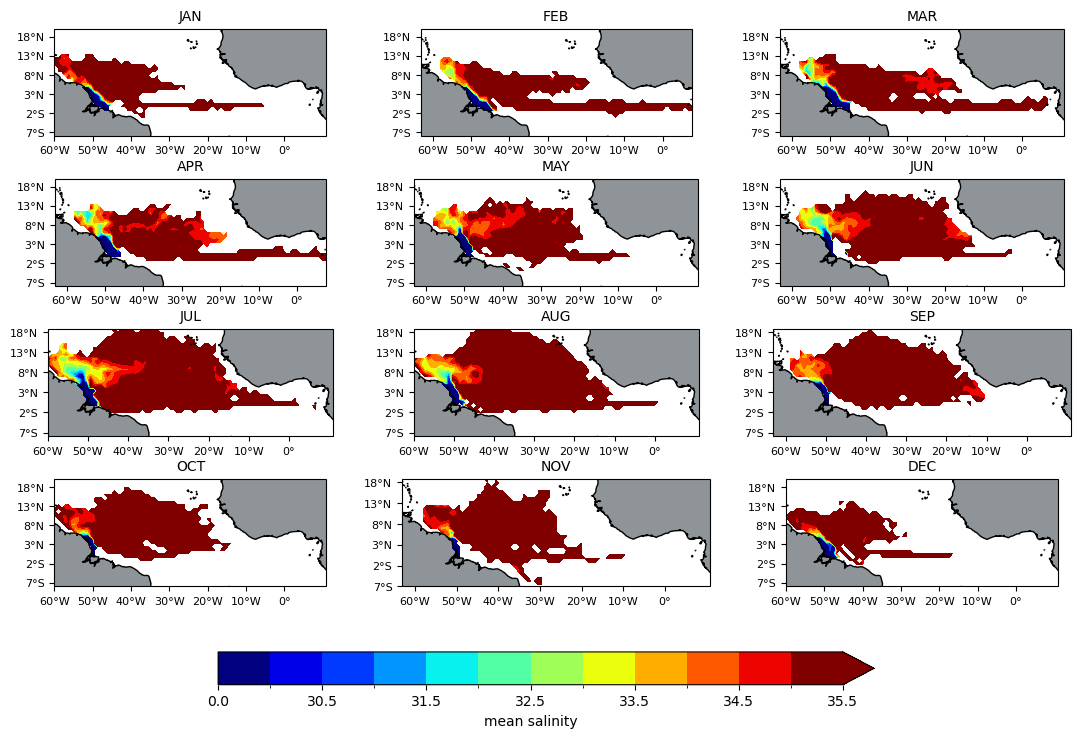

In [13]:
plot_monthly(mean_sal.sal, "sal")

## Now density and buoyancy

In [ ]:
p   = gsw.p_from_z(-ds_m.z, ds_m.lat)                 # real pressure at particle depth
SA  = gsw.SA_from_SP(ds_m.sal, p, ds_m.lon, ds_m.lat)  # practical -> absolute salinity
CT  = gsw.CT_from_pt(SA, ds_m.temp)                # potential -> conservative temp
rho = gsw.rho(SA, CT, p)                         # IN-SITU density (real p)

In [ ]:
## buoyancy
g = 9.81 #m/s2
rho_0 = 1025
b = -g * (rho - rho_0) / rho_0
b = b.rename('buoyancy')
b

In [ ]:
# potential density referenced to the surface (0 dbar)
rho_pot = gsw.rho(SA, CT, 0)

# convenience version: sigma0 = rho_pot - 1000
sigma0 = gsw.sigma0(SA, CT)          # e.g. 25.3 instead of 1025.3
sigma0 = sigma0.rename('sigma0')
sigma0

In [53]:
ds_m['b'] = b
ds_m['sigma0'] = sigma0
ds_m

<xarray.Dataset> Size: 6GB
Dimensions:      (trajectory: 149215, obs: 740)
Coordinates:
  * obs          (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 733 734 735 736 737 738 739
  * trajectory   (trajectory) int64 1MB 93 1850 2536 3213 ... 9374 9601 9757
Data variables:
    lat          (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    lon          (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    sal          (trajectory, obs) float32 442MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    temp         (trajectory, obs) float32 442MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    time         (trajectory, obs) datetime64[ns] 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    z            (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    start_time   (trajectory) datetime64[ns] 1MB 1993-01-06 ... 2013-08-20
    start_month  (trajectory) int64 1MB 1 1 1 1 1 1 1 1 1 ... 8 8 8 8 8 8 8 8 8
    start_year   (trajectory) int64 1MB 1993 1993 1993 1993 ... 2013 2013 2013
    b            (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
    sigma0       (trajectory, obs) float64 883MB dask.array<chunksize=(19, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [54]:
monthly_sigma0    = ds_m.groupby("start_month").apply(lambda d: calc_one(d, "sigma0")) #potential density
monthly_b    = ds_m.groupby("start_month").apply(lambda d: calc_one(d, "b")) #buoyancy

In [55]:
mean_sigma0    = monthly_mean(monthly_sigma0,    "sigma0")
mean_b = monthly_mean(monthly_b, "b")


# store each one separately (zarr)
mean_sigma0.to_dataset().to_zarr(f"mean_sigma0_month_{cluster}.zarr", mode="w")
mean_b.to_dataset().to_zarr(f"mean_b_month_{cluster}.zarr", mode="w")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 27.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 27.43 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [16]:
mean_sigma0 = xr.open_dataset(f'mean_sigma0_month_{cluster}.zarr').compute()
mean_b      = xr.open_dataset(f'mean_b_month_{cluster}.zarr').compute()

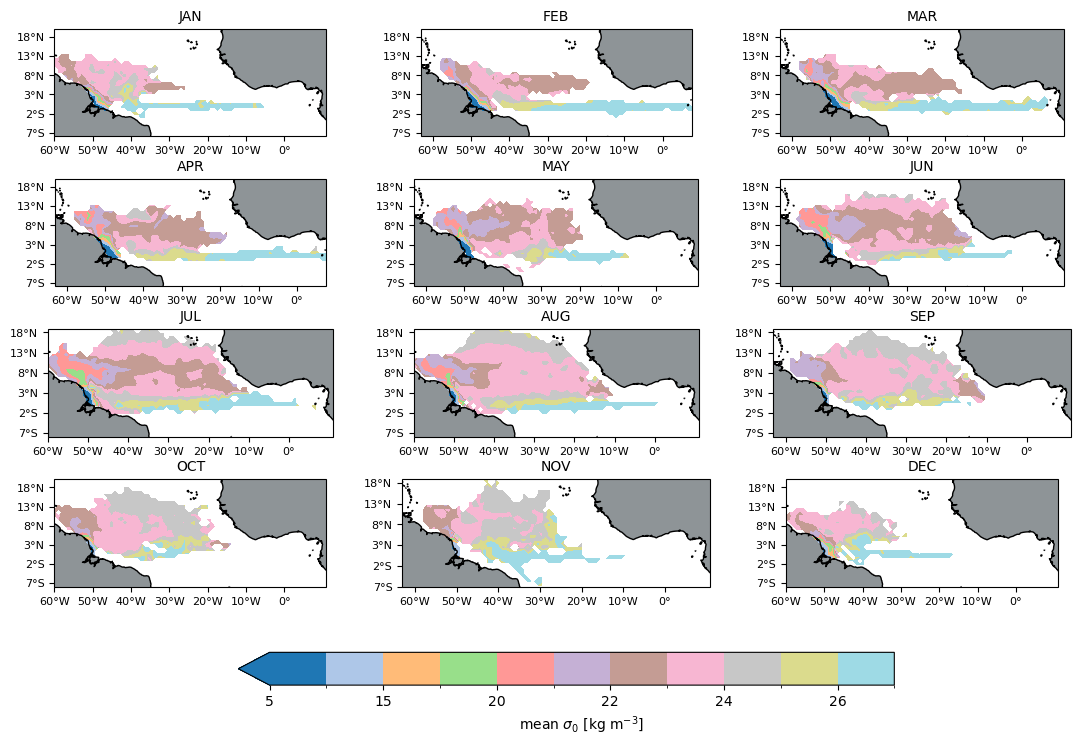

In [30]:
plot_monthly(mean_sigma0.sigma0, "sigma0")

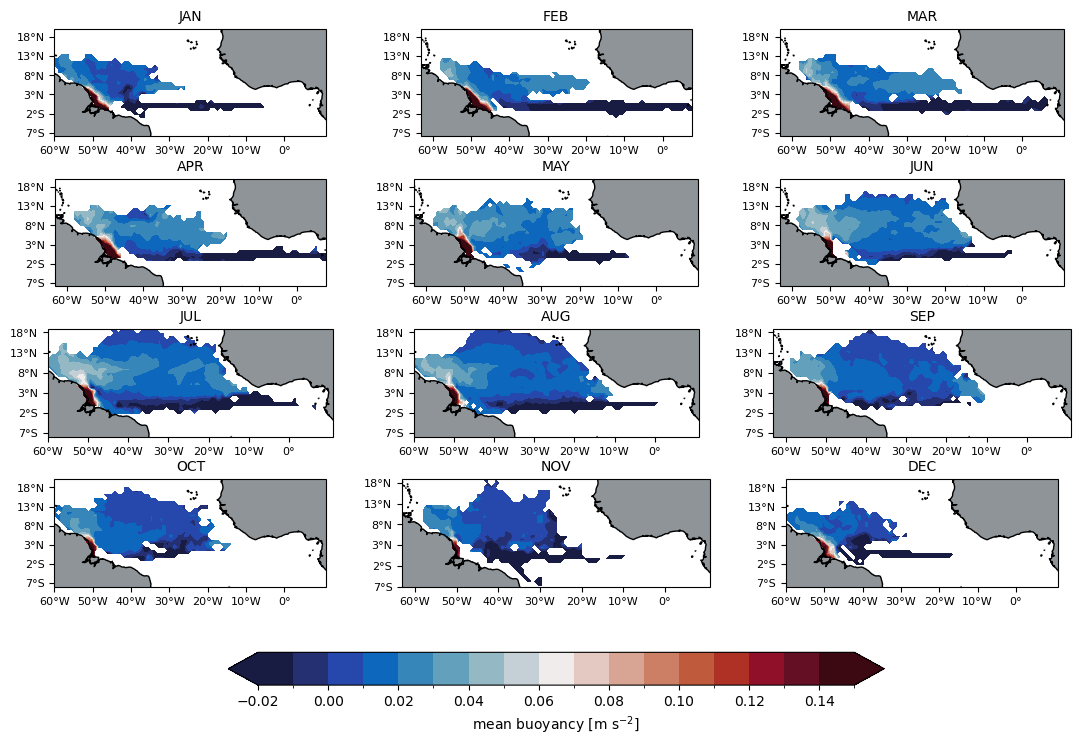

In [18]:
plot_monthly(mean_b.b, "b")

## Horizontal $\sigma_0$ gradient (density fronts / geostrophic shear)

`|∇σ₀|` on the monthly-mean field: large values mark density fronts (plume edge,
retroflection, NBC) and, via thermal wind, strong vertical shear of the
geostrophic flow. NB this is a Lagrangian depth-and-time-mixed mean, so read it
as *where the fronts are*, not as a quantitative geostrophic shear.

In [35]:
# horizontal gradient of monthly-mean sigma0 (metric-aware: cos(lat) on lon)
R     = 6371e3
deg2m = np.deg2rad(1) * R                       # metres per degree of latitude

s = mean_sigma0.sigma0
dsig_dx = s.differentiate("lon") / (deg2m * np.cos(np.deg2rad(s.lat)))
dsig_dy = s.differentiate("lat") /  deg2m
grad_sigma0 = (np.hypot(dsig_dx, dsig_dy) * 1e5).rename("grad_sigma0")  # kg m-3 / 100 km

# register in the plotting config (one entry per dict, like every other variable)
cmaps["grad_sigma0"]  = 'tab10'
labels["grad_sigma0"] = r"$|\nabla\sigma_0|$ [kg m$^{-3}$ / 100 km]"
LEVELS["grad_sigma0"] = np.arange(1.8, 4, 0.2)   # fronts (>2) saturate the top band

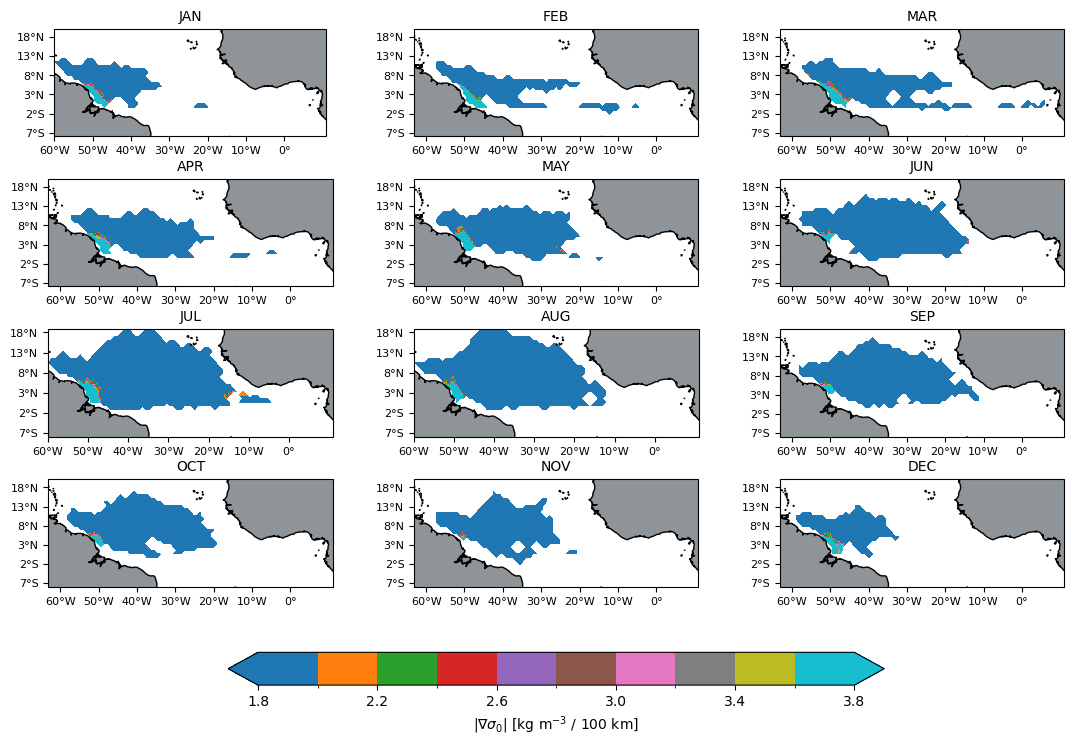

In [36]:
plot_monthly(grad_sigma0, "grad_sigma0")